## HW 1 ( 40 points)

#### Submit your homework as a. ipynb file. Use the format 'HW1_LastName_FirstName.ipynb'. If there are no comments/markdown describing what you have done, your work will not be graded. Follow the code of conduct. 

Q1. Write a function that reads the file words.txt and builds a list with each element being a single word (5).


In [1]:
import os

# Check the current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Check if the file exists in the current directory
file_path = 'words.txt'
if os.path.exists(file_path):
    print(f"File '{file_path}' exists.")
else:
    print(f"File '{file_path}' does not exist in the current directory.")
    print("Use `!ls` in a notebook cell to see available files.")

# Function to read the file
def read_words_from_file(file_path):
    """
    Reads a file and returns a list of words.

    Args:
        file_path (str): The path to the text file.

    Returns:
        list: A list where each element is a single word from the file.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            words = file.read().split()
            return words
    except Exception as e:
        print(f"An error occurred: {e}")
        return []

# Read the words if the file exists
if os.path.exists(file_path):
    word_list = read_words_from_file(file_path)
    print("Words in the file:")
    print(word_list)
else:
    print("Please check the file path and try again.")


Current working directory: /home/jovyan
File 'words.txt' exists.
Words in the file:
['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'A', 'Piece', 'of', 'Cake']


Q2. You are given a list and a dictionary. For the elements in the list that are same as the keys in the dictionary, replace those elements in the list with 'cheme' + the nth element of the value corresponding to that particular key in the dictionary. (10)

course_list = ['unit-operations','clean-energy','thermodynamics','math','data-science']
course_code = {'unit-operations': [510,410,310], 'thermodynamics':[375,475,575], 'data-science':[345,445,545]}
for n = 2, the output list should be printed:
output_list = ['cheme310','clean-energy','cheme575','math','cheme545']

In [2]:
# Define the function to process the list
def replace_elements_with_cheme(course_list, course_code, n):
    """
    Replaces elements in course_list with 'cheme' + nth element from course_code values.

    Args:
        course_list (list): List of course names.
        course_code (dict): Dictionary with course names as keys and list of codes as values.
        n (int): Index of the value to pick from the dictionary values (1-based index).

    Returns:
        list: Updated list with replacements.
    """
    # Ensure the index is 1-based and within range
    n_index = n - 1  # Convert 1-based to 0-based index
    updated_list = []  # Initialize an empty list for the updated values

    for course in course_list:
        if course in course_code:  # Check if the course is in the dictionary
            try:
                # Get the nth value from the dictionary's value list
                new_value = f"cheme{course_code[course][n_index]}"
                updated_list.append(new_value)
            except IndexError:
                print(f"Index {n} is out of range for course '{course}'.")
                updated_list.append(course)  # Keep the original value if index is out of range
        else:
            # Keep the original course name if it doesn't match any key
            updated_list.append(course)

    return updated_list

# Input data
course_list = ['unit-operations', 'clean-energy', 'thermodynamics', 'math', 'data-science']
course_code = {
    'unit-operations': [510, 410, 310],
    'thermodynamics': [375, 475, 575],
    'data-science': [345, 445, 545]
}

# Specify the value of n
n = 2  # 1-based index

# Call the function
output_list = replace_elements_with_cheme(course_list, course_code, n)

# Print the results
print("Updated course list:")
print(output_list)


Updated course list:
['cheme410', 'clean-energy', 'cheme475', 'math', 'cheme445']


Q3. Given a CSV file (marks.csv) where each row contains the name followed by the subject-wise marks of a student, print out the name and the average score for each of the students. You can assume that each student appears in the same number of subjects.(10)


In [5]:
import pandas as pd

def calculate_average_marks(file_path):
    """
    Reads an Excel file containing students' names and marks and calculates the average for each student.

    Args:
        file_path (str): The path to the Excel file.

    Returns:
        pd.DataFrame: A DataFrame with students' names and their average marks.
    """
    try:
        # Read the Excel file into a DataFrame
        data = pd.read_excel(file_path)
        
        # Assume the first column contains student names
        # All subsequent columns contain marks
        students = data.iloc[:, 0]  # First column: student names
        marks = data.iloc[:, 1:]    # All other columns: marks
        
        # Calculate the average for each student
        average_marks = marks.mean(axis=1)
        
        # Combine names with average marks into a new DataFrame
        result = pd.DataFrame({
            'Name': students,
            'Average Marks': average_marks
        })
        
        return result
    except Exception as e:
        print(f"An error occurred: {e}")
        return pd.DataFrame()

# Specify the path to the marks.xlsx file
file_path = 'marks.xlsx'  # Adjust if necessary

# Read and process the data
average_marks_df = calculate_average_marks(file_path)

# Display the results
if not average_marks_df.empty:
    print("Student Average Marks:")
    print(average_marks_df)
else:
    print("No data to display.")


Student Average Marks:
  Name  Average Marks
0  aaa           89.8
1  bbb           83.6
2  ccc           81.2
3  ddd           87.6
4  eee           88.4
5  fff           93.4
6  ggg           87.8
7  hhh           89.4


Q4: Load the given dataset ‘wine_exp.csv’.  The inputs include objective tests (e.g., acidity, alcohol content, etc.) and the output is based on sensory data (median of at least 3 evaluations made by wine experts). Each expert graded the wine quality between 0 (very bad) and 10 (very excellent). All the plots should have a title and axis labels. (15)

a) Develop a multiple linear regression (MLR) model on this dataset with a 20% split for the test data and a random state of 250. Print the R2 values of the resultant model on the test data.

b) Do data preprocessing (make the mean zero and divide by the standard deviation for each feature) and update the MLR with this new preprocessed data. Pick any one feature, plot the scatter plot of that feature on the x-axis and wine quality on the y-axis. 

Wine dataset loaded successfully!
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9

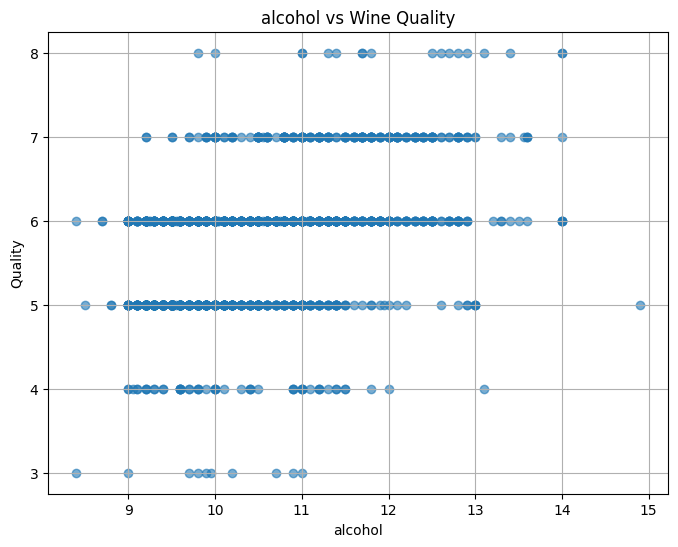

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Load the dataset
def load_wine_dataset(file_path):
    """
    Loads the wine dataset from a text file.

    Args:
        file_path (str): Path to the text file.

    Returns:
        pd.DataFrame: DataFrame containing the wine dataset.
    """
    try:
        # Read the dataset with ";" as the delimiter
        data = pd.read_csv(file_path, sep=";")
        return data
    except Exception as e:
        print(f"An error occurred while loading the dataset: {e}")
        return pd.DataFrame()

# Perform multiple linear regression
def perform_mlr(data, test_size=0.2, random_state=250):
    """
    Performs multiple linear regression on the given dataset.

    Args:
        data (pd.DataFrame): The wine dataset.
        test_size (float): Proportion of test data.
        random_state (int): Random state for train-test split.

    Returns:
        tuple: LinearRegression model, R² score for test data, test data (X_test, y_test).
    """
    # Separate features (X) and target (y)
    X = data.drop(columns=["quality"])
    y = data["quality"]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # Initialize and fit the linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    return model, r2, (X_test, y_test)

# Preprocess data and re-run MLR
def preprocess_and_plot(data, feature_name, model, X_test, y_test):
    """
    Preprocesses the dataset (standardization) and plots a scatter plot for a feature vs wine quality.

    Args:
        data (pd.DataFrame): The wine dataset.
        feature_name (str): Name of the feature to plot.
        model (LinearRegression): Trained model.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target.

    Returns:
        None
    """
    # Standardize the features
    scaler = StandardScaler()
    X = data.drop(columns=["quality"])
    X_scaled = scaler.fit_transform(X)
    
    # Create a new DataFrame with scaled features
    data_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    data_scaled["quality"] = data["quality"]
    
    # Plot the selected feature against wine quality
    plt.figure(figsize=(8, 6))
    plt.scatter(data[feature_name], data["quality"], alpha=0.6)
    plt.title(f"{feature_name} vs Wine Quality")
    plt.xlabel(feature_name)
    plt.ylabel("Quality")
    plt.grid(True)
    plt.show()

# File path to wine dataset
file_path = 'wine.txt'  # Adjust to the actual location in your environment

# Load dataset
data = load_wine_dataset(file_path)

if not data.empty:
    print("Wine dataset loaded successfully!")
    print(data.head())
    
    # Perform MLR
    model, r2, (X_test, y_test) = perform_mlr(data)
    print(f"R² score on test data (original): {r2:.4f}")
    
    # Choose a feature to plot against wine quality
    feature_name = "alcohol"  # Replace with any feature you want to analyze
    preprocess_and_plot(data, feature_name, model, X_test, y_test)
else:
    print("Failed to load the dataset. Please check the file path and format.")
